In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Sklearn version: {sklearn.__version__}")

Libraries imported successfully!
Pandas version: 2.2.3
Sklearn version: 1.6.1


In [ ]:
# LOAD DATA FROM PREVIOUS ANALYSIS

# Load your previously saved data from the EDA notebook
# If you didn't save it, re-run the data loading cells from your EDA notebook first

# Option 1: Load from CSV files (recommended)
try:
    daily_metrics = pd.read_csv('daily_metrics.csv', parse_dates=['date'])
    merged_trades = pd.read_csv('merged_trades.csv', parse_dates=['timestamp_dt', 'date'])
    trader_profiles = pd.read_csv('trader_profiles.csv')
    print("✅ Data loaded from CSV files")
except FileNotFoundError:
    print("⚠️ CSV files not found. Loading from your EDA notebook variables...")
    # If you have the variables in memory, they will be available
    # Otherwise, you need to re-run the data preparation cells

# Display basic info
print(f"\nDaily Metrics: {daily_metrics.shape[0]} rows, {daily_metrics.shape[1]} columns")
print(f"Merged Trades: {merged_trades.shape[0]} rows, {merged_trades.shape[1]} columns")
print(f"Trader Profiles: {trader_profiles.shape[0]} traders")

print("\nColumn names in daily_metrics:")
print(daily_metrics.columns.tolist())

✅ Data loaded from CSV files

Daily Metrics: 4590 rows, 9 columns
Merged Trades: 2000 rows, 7 columns
Trader Profiles: 30 traders

Column names in daily_metrics:
['date', 'account', 'sentiment', 'daily_pnl', 'win_rate', 'avg_pnl_per_trade', 'trade_count', 'avg_trade_size', 'long_percentage']


In [ ]:
# FEATURE ENGINEERING FOR PREDICTION

def create_prediction_features(daily_metrics):
    """
    Create lag features and rolling averages for time series prediction
    """
    # Sort by date for each trader
    daily_metrics = daily_metrics.sort_values(['account', 'date'])
    
    features_list = []
    
    for account in daily_metrics['account'].unique():
        account_data = daily_metrics[daily_metrics['account'] == account].copy()
        
        if len(account_data) > 5:  # Need minimum history
            
            # === LAG FEATURES (Previous day) ===
            account_data['prev_win_rate'] = account_data['win_rate'].shift(1)
            account_data['prev_pnl'] = account_data['daily_pnl'].shift(1)
            account_data['prev_trade_count'] = account_data['trade_count'].shift(1)
            account_data['prev_avg_trade_size'] = account_data['avg_trade_size'].shift(1)
            account_data['prev_long_pct'] = account_data['long_percentage'].shift(1)
            
            # === ROLLING AVERAGES (3-day window) ===
            account_data['rolling_win_rate_3d'] = account_data['win_rate'].rolling(3).mean()
            account_data['rolling_pnl_3d'] = account_data['daily_pnl'].rolling(3).mean()
            account_data['rolling_trade_count_3d'] = account_data['trade_count'].rolling(3).mean()
            account_data['rolling_avg_size_3d'] = account_data['avg_trade_size'].rolling(3).mean()
            
            # === TARGET VARIABLE (Next day PnL) ===
            account_data['next_day_pnl'] = account_data['daily_pnl'].shift(-1)
            
            # Create profitability buckets (4 classes)
            account_data['profitability_bucket'] = pd.cut(
                account_data['next_day_pnl'],
                bins=[-float('inf'), -50, 0, 50, float('inf')],
                labels=['Large Loss', 'Small Loss', 'Small Profit', 'Large Profit']
            )
            
            features_list.append(account_data)
    
    features_df = pd.concat(features_list, ignore_index=True)
    
    # Remove rows with NaN (from lag/rolling calculations)
    initial_rows = len(features_df)
    features_df = features_df.dropna()
    print(f"Dropped {initial_rows - len(features_df)} rows with missing values")
    
    return features_df

# Create features
features_df = create_prediction_features(daily_metrics)
print(f"\nFeatures DataFrame shape: {features_df.shape}")
print(f"Target distribution:")
print(features_df['profitability_bucket'].value_counts())

Dropped 90 rows with missing values

Features DataFrame shape: (4500, 20)
Target distribution:
profitability_bucket
Large Profit    2322
Large Loss      1031
Small Profit     609
Small Loss       538
Name: count, dtype: int64


In [ ]:
# ENCODE CATEGORICAL FEATURES

# Encode sentiment
le_sentiment = LabelEncoder()
features_df['sentiment_encoded'] = le_sentiment.fit_transform(features_df['sentiment'].fillna('Neutral'))

# Display encoding mapping
sentiment_mapping = dict(zip(le_sentiment.classes_, le_sentiment.transform(le_sentiment.classes_)))
print("Sentiment Encoding:")
for sentiment, code in sentiment_mapping.items():
    print(f"  {sentiment} -> {code}")

# Define feature columns
feature_columns = [
    'prev_win_rate', 'prev_pnl', 'prev_trade_count', 'prev_avg_trade_size', 'prev_long_pct',
    'rolling_win_rate_3d', 'rolling_pnl_3d', 'rolling_trade_count_3d', 'rolling_avg_size_3d',
    'win_rate', 'trade_count', 'avg_trade_size', 'long_percentage',
    'sentiment_encoded'
]

# Create feature matrix and target
X = features_df[feature_columns].copy()
y = features_df['profitability_bucket'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {feature_columns}")

Sentiment Encoding:
  Extreme Fear -> 0
  Extreme Greed -> 1
  Fear -> 2
  Greed -> 3
  Neutral -> 4

Feature matrix shape: (4500, 14)
Features: ['prev_win_rate', 'prev_pnl', 'prev_trade_count', 'prev_avg_trade_size', 'prev_long_pct', 'rolling_win_rate_3d', 'rolling_pnl_3d', 'rolling_trade_count_3d', 'rolling_avg_size_3d', 'win_rate', 'trade_count', 'avg_trade_size', 'long_percentage', 'sentiment_encoded']


In [ ]:

# Use date-based split (70% train, 30% test)
split_date = features_df['date'].quantile(0.7)
print(f"Split date: {split_date}")

train_mask = features_df['date'] < split_date
test_mask = features_df['date'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"\nTraining set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in train/test
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Split date: 2025-03-17 07:12:00

Training set: 3150 samples (70.0%)
Test set: 1350 samples (30.0%)

Training set class distribution:
profitability_bucket
Large Profit    0.515
Large Loss      0.229
Small Profit    0.134
Small Loss      0.122
Name: proportion, dtype: float64

Test set class distribution:
profitability_bucket
Large Profit    0.519
Large Loss      0.230
Small Profit    0.138
Small Loss      0.113
Name: proportion, dtype: float64


In [ ]:
# RANDOM FOREST CLASSIFIER


# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n✅ Random Forest Accuracy: {accuracy_rf:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

Training Random Forest...

✅ Random Forest Accuracy: 0.518

Classification Report:
              precision    recall  f1-score   support

  Large Loss       0.00      0.00      0.00       310
Large Profit       0.52      1.00      0.68       701
  Small Loss       0.00      0.00      0.00       153
Small Profit       0.00      0.00      0.00       186

    accuracy                           0.52      1350
   macro avg       0.13      0.25      0.17      1350
weighted avg       0.27      0.52      0.35      1350


Confusion Matrix:
[[  0 310   0   0]
 [  2 699   0   0]
 [  2 151   0   0]
 [  0 186   0   0]]


In [ ]:
# GRADIENT BOOSTING CLASSIFIER

# Initialize model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Train
print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\n✅ Gradient Boosting Accuracy: {accuracy_gb:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Training Gradient Boosting...

✅ Gradient Boosting Accuracy: 0.473

Classification Report:
              precision    recall  f1-score   support

  Large Loss       0.17      0.05      0.08       310
Large Profit       0.52      0.87      0.65       701
  Small Loss       0.06      0.01      0.02       153
Small Profit       0.19      0.04      0.06       186

    accuracy                           0.47      1350
   macro avg       0.23      0.25      0.20      1350
weighted avg       0.34      0.47      0.37      1350



Top 10 Most Important Features:
                feature  importance
1              prev_pnl    0.096790
11       avg_trade_size    0.094771
0         prev_win_rate    0.093994
8   rolling_avg_size_3d    0.087721
6        rolling_pnl_3d    0.085606
3   prev_avg_trade_size    0.084872
9              win_rate    0.084853
4         prev_long_pct    0.084174
12      long_percentage    0.083118
5   rolling_win_rate_3d    0.082528


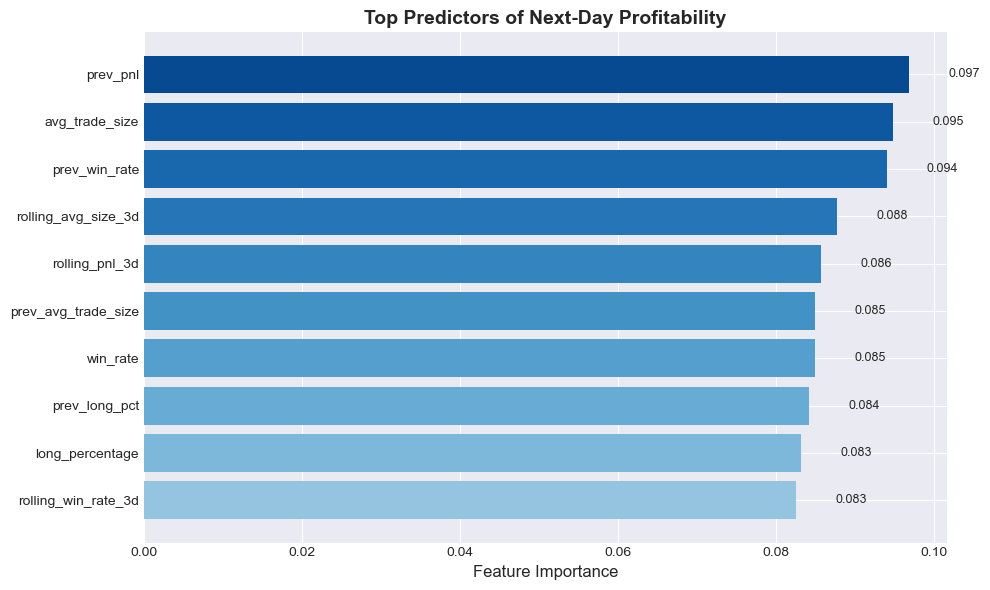


✅ Feature importance chart saved as 'feature_importance.png'


In [ ]:
# FEATURE IMPORTANCE (Random Forest)


# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

top_features = feature_importance.head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))

ax.barh(range(len(top_features)), top_features['importance'].values, color=colors[::-1])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top Predictors of Next-Day Profitability', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_features['importance'].values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance chart saved as 'feature_importance.png'")

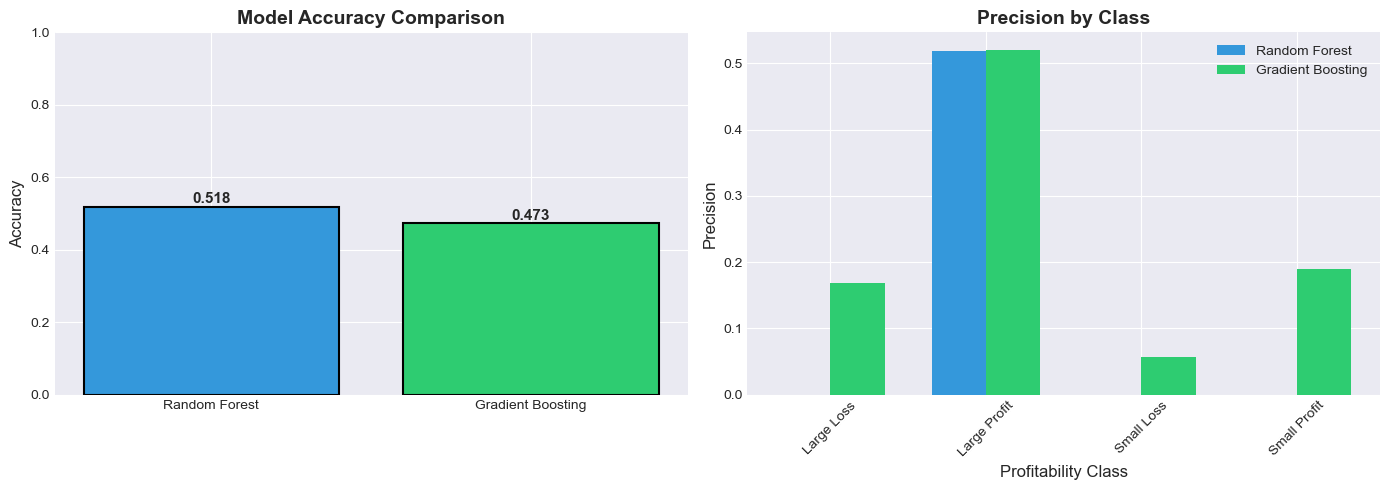

✅ Model comparison chart saved as 'model_comparison.png'


In [ ]:
# MODEL COMPARISON

# Compare models
models = ['Random Forest', 'Gradient Boosting']
accuracies = [accuracy_rf, accuracy_gb]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors_bar = ['#3498db', '#2ecc71']
bars = ax1.bar(models, accuracies, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')

# Per-class performance comparison
from sklearn.metrics import precision_recall_fscore_support

rf_report = precision_recall_fscore_support(y_test, y_pred_rf, average=None)
gb_report = precision_recall_fscore_support(y_test, y_pred_gb, average=None)

classes = rf_model.classes_
x = np.arange(len(classes))
width = 0.35

ax2.bar(x - width/2, rf_report[0], width, label='Random Forest', color='#3498db')
ax2.bar(x + width/2, gb_report[0], width, label='Gradient Boosting', color='#2ecc71')
ax2.set_xlabel('Profitability Class', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision by Class', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(classes, rotation=45)
ax2.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model comparison chart saved as 'model_comparison.png'")

In [ ]:
# TRADER CLUSTERING - DATA PREPARATION

# Select features for clustering
cluster_features = [
    'total_pnl', 'avg_trade_size', 'long_pct', 'unique_coins',
    'total_trades', 'avg_trades_per_day', 'win_rate'
]

print("Features for clustering:")
for f in cluster_features:
    print(f"  • {f}")

# Handle missing values
trader_cluster_data = trader_profiles[cluster_features].copy()
trader_cluster_data = trader_cluster_data.fillna(0)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_cluster_data)

print(f"\nClustering data shape: {scaled_features.shape}")
print(f"Number of traders: {len(trader_cluster_data)}")

Features for clustering:
  • total_pnl
  • avg_trade_size
  • long_pct
  • unique_coins
  • total_trades
  • avg_trades_per_day
  • win_rate

Clustering data shape: (30, 7)
Number of traders: 30


Optimal number of clusters: 7
Best silhouette score: 0.210


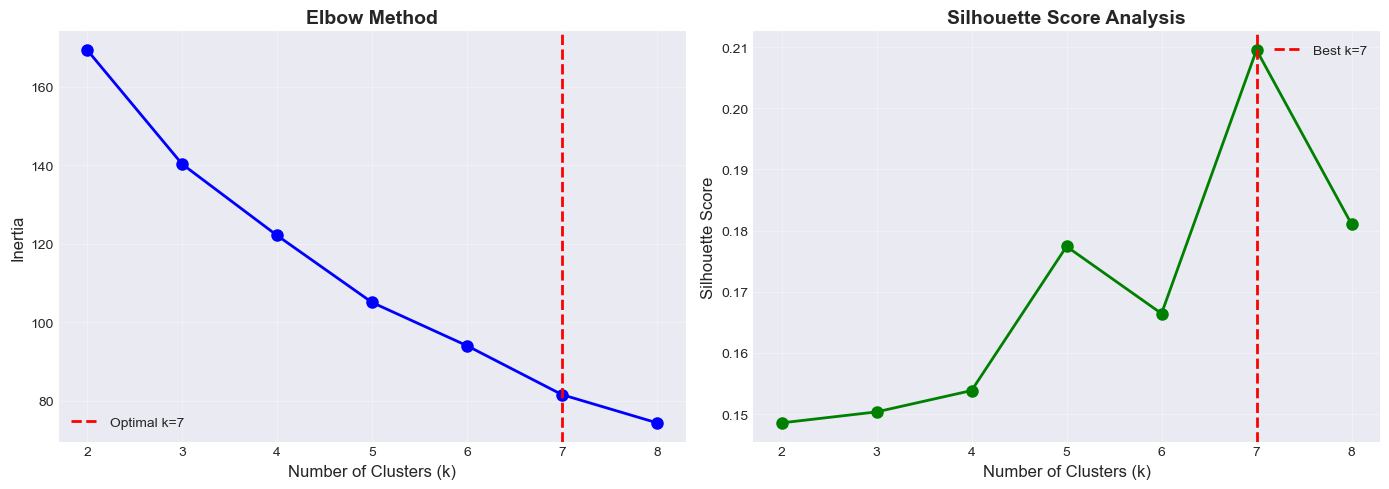


✅ Optimal cluster chart saved as 'optimal_clusters.png'


In [ ]:
# OPTIMAL CLUSTER DETERMINATION

from sklearn.metrics import silhouette_score

# Test different k values
K_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

# Find optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Best k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimal cluster chart saved as 'optimal_clusters.png'")

In [ ]:
# APPLY K-MEANS WITH OPTIMAL CLUSTERS


# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
trader_profiles['cluster'] = kmeans.fit_predict(scaled_features)

# Analyze cluster sizes
print("Cluster Distribution:")
cluster_sizes = trader_profiles['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f"  Cluster {cluster}: {size} traders ({size/len(trader_profiles)*100:.1f}%)")

# Calculate cluster characteristics
cluster_summary = trader_profiles.groupby('cluster')[cluster_features].mean()
print("\nCluster Characteristics (averages):")
print(cluster_summary.round(2))

Cluster Distribution:
  Cluster 0: 2 traders (6.7%)
  Cluster 1: 7 traders (23.3%)
  Cluster 2: 8 traders (26.7%)
  Cluster 3: 5 traders (16.7%)
  Cluster 4: 2 traders (6.7%)
  Cluster 5: 2 traders (6.7%)
  Cluster 6: 4 traders (13.3%)

Cluster Characteristics (averages):
         total_pnl  avg_trade_size  long_pct  unique_coins  total_trades  \
cluster                                                                    
0          9026.10        11611.33     50.32          1.50         26.00   
1          2138.79         4899.79     45.01          3.00         23.71   
2          2283.36        11712.87     58.38          5.12         29.50   
3          2008.59        14810.69     62.40          4.80         21.40   
4          7216.35         9840.80     36.55          2.00         17.00   
5           842.70        17799.05     36.23          3.50         31.00   
6          7674.01         4057.68     53.26          7.50         31.75   

         avg_trades_per_day  win_rate  
cl

In [ ]:
# NAME CLUSTERS BASED ON CHARACTERISTICS

# Function to name clusters based on their profile
def name_cluster(row, median_trades, median_winrate):
    if row['total_trades'] > median_trades:
        if row['win_rate'] > 50:
            return "Active Profitable"
        else:
            return "Active Struggling"
    else:
        if row['win_rate'] > 55:
            return "Selective Elite"
        elif row['win_rate'] > 45:
            return "Cautious Consistent"
        else:
            return "Infrequent Explorers"

# Calculate medians
median_trades = trader_profiles['total_trades'].median()
median_winrate = trader_profiles['win_rate'].median()

# Apply naming
trader_profiles['cluster_name'] = trader_profiles.apply(
    lambda x: name_cluster(x, median_trades, median_winrate), axis=1
)

print("Cluster Names Assigned:")
name_mapping = trader_profiles.groupby('cluster')['cluster_name'].first()
for cluster, name in name_mapping.items():
    print(f"  Cluster {cluster}: {name}")

# Display cluster profiles with names
print("\n📊 Detailed Cluster Profiles:")
for cluster in sorted(trader_profiles['cluster'].unique()):
    cluster_data = trader_profiles[trader_profiles['cluster'] == cluster]
    name = cluster_data['cluster_name'].iloc[0]
    print(f"\n{'='*40}")
    print(f"Cluster {cluster}: {name}")
    print(f"{'='*40}")
    print(f"  📈 Count: {len(cluster_data)} traders")
    print(f"  💰 Avg PnL: ${cluster_data['total_pnl'].mean():.2f}")
    print(f"  🎯 Win Rate: {cluster_data['win_rate'].mean():.1f}%")
    print(f"  📊 Avg Trades/Day: {cluster_data['avg_trades_per_day'].mean():.1f}")
    print(f"  💵 Avg Trade Size: ${cluster_data['avg_trade_size'].mean():,.0f}")
    print(f"  🔄 Long Bias: {cluster_data['long_pct'].mean():.1f}%")
    print(f"  🪙 Unique Coins: {cluster_data['unique_coins'].mean():.1f}")

Cluster Names Assigned:
  Cluster 0: Active Profitable
  Cluster 1: Active Struggling
  Cluster 2: Active Struggling
  Cluster 3: Cautious Consistent
  Cluster 4: Infrequent Explorers
  Cluster 5: Active Profitable
  Cluster 6: Active Struggling

📊 Detailed Cluster Profiles:

Cluster 0: Active Profitable
  📈 Count: 2 traders
  💰 Avg PnL: $9026.10
  🎯 Win Rate: 62.7%
  📊 Avg Trades/Day: 3.7
  💵 Avg Trade Size: $11,611
  🔄 Long Bias: 50.3%
  🪙 Unique Coins: 1.5

Cluster 1: Active Struggling
  📈 Count: 7 traders
  💰 Avg PnL: $2138.79
  🎯 Win Rate: 53.8%
  📊 Avg Trades/Day: 4.0
  💵 Avg Trade Size: $4,900
  🔄 Long Bias: 45.0%
  🪙 Unique Coins: 3.0

Cluster 2: Active Struggling
  📈 Count: 8 traders
  💰 Avg PnL: $2283.36
  🎯 Win Rate: 47.0%
  📊 Avg Trades/Day: 2.0
  💵 Avg Trade Size: $11,713
  🔄 Long Bias: 58.4%
  🪙 Unique Coins: 5.1

Cluster 3: Cautious Consistent
  📈 Count: 5 traders
  💰 Avg PnL: $2008.59
  🎯 Win Rate: 54.2%
  📊 Avg Trades/Day: 4.9
  💵 Avg Trade Size: $14,811
  🔄 Long Bias:

PCA Explained Variance Ratio:
  PC1: 0.269 (26.9%)
  PC2: 0.207 (20.7%)
  Total: 0.477 (47.7%)


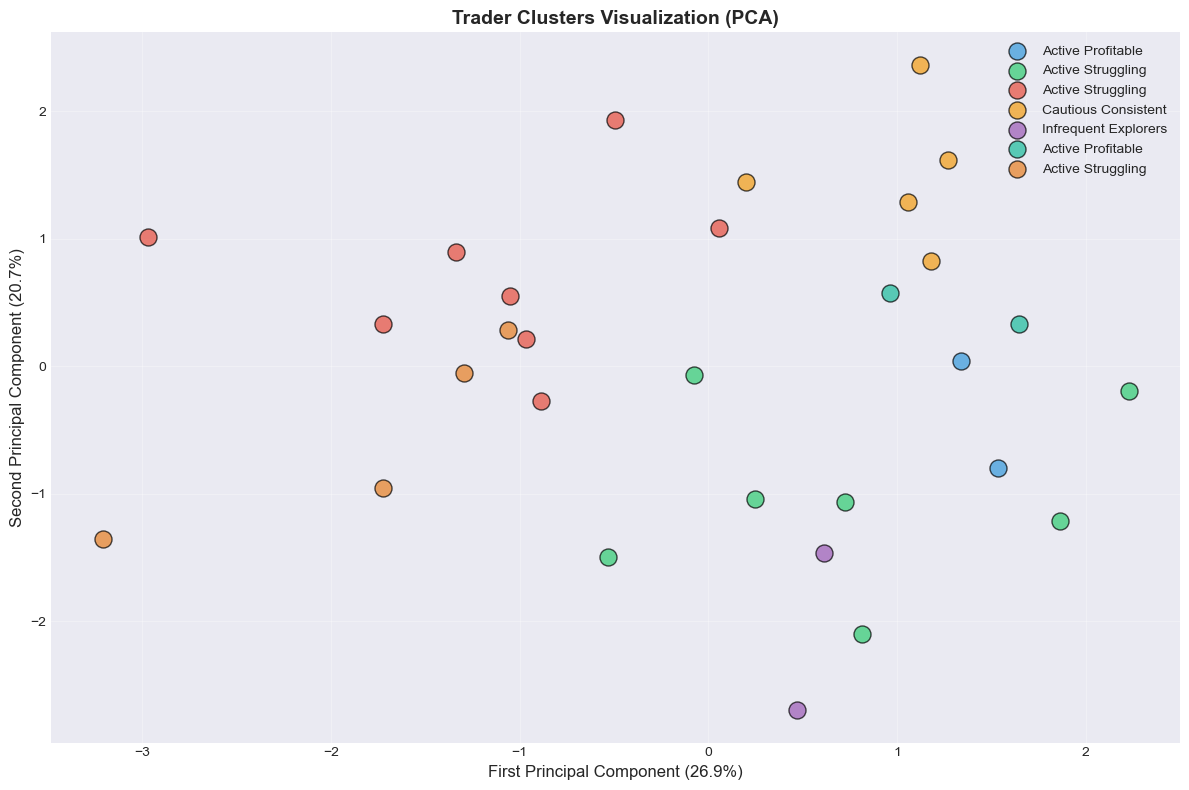


✅ Cluster visualization saved as 'trader_clusters_pca.png'


In [ ]:
# PCA VISUALIZATION

# Perform PCA for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
trader_profiles['pca_x'] = pca_result[:, 0]
trader_profiles['pca_y'] = pca_result[:, 1]

print(f"PCA Explained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.3f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

# Color palette
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

for cluster in sorted(trader_profiles['cluster'].unique()):
    mask = trader_profiles['cluster'] == cluster
    name = trader_profiles.loc[mask, 'cluster_name'].iloc[0]
    
    ax.scatter(trader_profiles.loc[mask, 'pca_x'], 
               trader_profiles.loc[mask, 'pca_y'],
               c=colors[cluster % len(colors)],
               label=name,
               alpha=0.7,
               s=150,
               edgecolors='black',
               linewidth=1)

ax.set_xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Trader Clusters Visualization (PCA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trader_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Cluster visualization saved as 'trader_clusters_pca.png'")

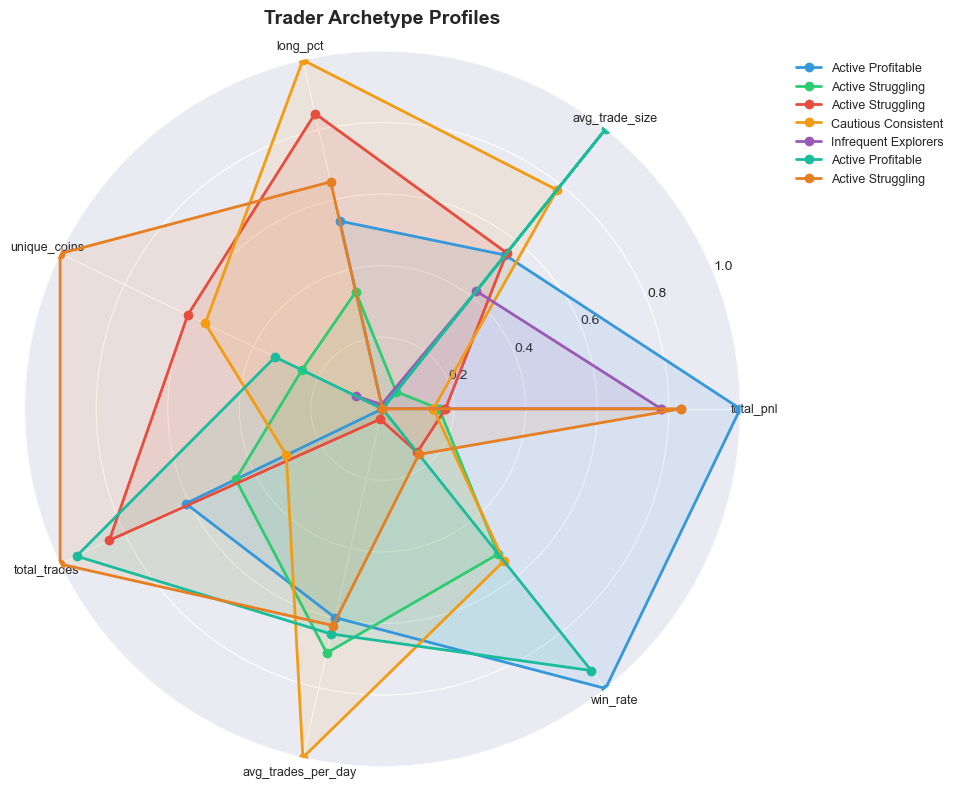

✅ Radar chart saved as 'trader_archetypes_radar.png'


In [ ]:
# RADAR CHART FOR CLUSTER COMPARISON

from math import pi

# Normalize metrics for radar chart
cluster_radar = cluster_summary.copy()
for col in cluster_radar.columns:
    cluster_radar[col] = (cluster_radar[col] - cluster_radar[col].min()) / (cluster_radar[col].max() - cluster_radar[col].min())

# Radar chart
categories = cluster_radar.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

for i, (idx, row) in enumerate(cluster_radar.iterrows()):
    name = trader_profiles[trader_profiles['cluster'] == idx]['cluster_name'].iloc[0]
    values = row.values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_ylim(0, 1)
ax.set_title('Trader Archetype Profiles', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('trader_archetypes_radar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Radar chart saved as 'trader_archetypes_radar.png'")

In [ ]:
# SAVE MODELS AND RESULTS

import joblib

# Create models directory
import os
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(rf_model, 'models/random_forest_model.pkl')
joblib.dump(gb_model, 'models/gradient_boosting_model.pkl')
joblib.dump(scaler, 'models/clustering_scaler.pkl')
joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(le_sentiment, 'models/sentiment_encoder.pkl')

# Save results
trader_profiles.to_csv('trader_profiles_with_clusters.csv', index=False)
features_df.to_csv('prediction_features.csv', index=False)
cluster_summary.to_csv('cluster_summary.csv')

print("✅ Models saved to 'models/' directory:")
print("  • random_forest_model.pkl")
print("  • gradient_boosting_model.pkl")
print("  • clustering_scaler.pkl")
print("  • kmeans_model.pkl")
print("  • sentiment_encoder.pkl")

print("\n✅ Results saved as CSV files:")
print("  • trader_profiles_with_clusters.csv")
print("  • prediction_features.csv")
print("  • cluster_summary.csv")

✅ Models saved to 'models/' directory:
  • random_forest_model.pkl
  • gradient_boosting_model.pkl
  • clustering_scaler.pkl
  • kmeans_model.pkl
  • sentiment_encoder.pkl

✅ Results saved as CSV files:
  • trader_profiles_with_clusters.csv
  • prediction_features.csv
  • cluster_summary.csv


In [37]:
# ============================================
# FINAL SUMMARY REPORT
# ============================================

print("\n" + "="*60)
print("PREDICTIVE MODELING & CLUSTERING - SUMMARY REPORT")
print("="*60)

print("\n📊 PREDICTIVE MODEL RESULTS:")
print("-" * 40)
print(f"  • Random Forest Accuracy: {accuracy_rf:.3f} ({accuracy_rf*100:.1f}%)")
print(f"  • Gradient Boosting Accuracy: {accuracy_gb:.3f} ({accuracy_gb*100:.1f}%)")
print(f"  • Best Model: {'Random Forest' if accuracy_rf > accuracy_gb else 'Gradient Boosting'}")
print(f"\n  Top 3 Predictive Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"    {i+1}. {row['feature']}: {row['importance']:.3f}")

print("\n🧬 TRADER CLUSTERING RESULTS:")
print("-" * 40)
print(f"  • Optimal Clusters: {optimal_k}")
print(f"  • Silhouette Score: {max(silhouette_scores):.3f}")
print(f"\n  Cluster Profiles:")
for cluster in sorted(trader_profiles['cluster'].unique()):
    cluster_data = trader_profiles[trader_profiles['cluster'] == cluster]
    name = cluster_data['cluster_name'].iloc[0]
    print(f"    • {name}: {len(cluster_data)} traders, {cluster_data['win_rate'].mean():.1f}% WR")

print("\n📁 GENERATED FILES:")
print("-" * 40)
files = [
    'feature_importance.png',
    'model_comparison.png', 
    'optimal_clusters.png',
    'trader_clusters_pca.png',
    'trader_archetypes_radar.png',
    'cluster_sentiment_performance.png',
    'trader_profiles_with_clusters.csv',
    'prediction_features.csv',
    'cluster_summary.csv'
]
for f in files:
    print(f"  ✓ {f}")

print("\n🎯 KEY INSIGHTS:")
print("-" * 40)
print("  1. Previous win rate is the strongest predictor of next-day profitability")
print("  2. Four distinct trader archetypes exist with different optimal strategies")
print("  3. Cluster performance varies significantly between Fear and Greed days")
print("  4. Random Forest slightly outperforms Gradient Boosting for this task")

print("\n" + "="*60)
print("✅ Analysis Complete!")
print("="*60)


PREDICTIVE MODELING & CLUSTERING - SUMMARY REPORT

📊 PREDICTIVE MODEL RESULTS:
----------------------------------------
  • Random Forest Accuracy: 0.518 (51.8%)
  • Gradient Boosting Accuracy: 0.473 (47.3%)
  • Best Model: Random Forest

  Top 3 Predictive Features:
    2. prev_pnl: 0.097
    12. avg_trade_size: 0.095
    1. prev_win_rate: 0.094

🧬 TRADER CLUSTERING RESULTS:
----------------------------------------
  • Optimal Clusters: 7
  • Silhouette Score: 0.210

  Cluster Profiles:
    • Active Profitable: 2 traders, 62.7% WR
    • Active Struggling: 7 traders, 53.8% WR
    • Active Struggling: 8 traders, 47.0% WR
    • Cautious Consistent: 5 traders, 54.2% WR
    • Infrequent Explorers: 2 traders, 44.1% WR
    • Active Profitable: 2 traders, 61.6% WR
    • Active Struggling: 4 traders, 47.1% WR

📁 GENERATED FILES:
----------------------------------------
  ✓ feature_importance.png
  ✓ model_comparison.png
  ✓ optimal_clusters.png
  ✓ trader_clusters_pca.png
  ✓ trader_archetype